# Educational Video Classification with Logistic Regression

This notebook implements a machine learning pipeline to classify YouTube videos as educational (1) or non-educational (0) based on video metadata using Logistic Regression.

## Dataset Overview
- **Source**: Combined normalized JSONL files from Clarigo dataset
- **Features**: Video title, channel name, video URL
- **Target**: Binary classification (0: non-educational, 1: educational)
- **Total Records**: ~3,024 videos

## 1. Import Libraries and Load Data


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load the current training dataset (broad-v1).
# The notebook lives in ml/notebooks/, so the ML root is its parent.
import os
notebook_dir = Path(os.getcwd())
ml_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir

# Current pipeline output (built by ml/scripts/build_broad_dataset.py).
data_path = ml_root / "data" / "processed_data" / "master_broad_v1.csv"
# To reproduce the original STEM-strict model instead, use the frozen legacy set:
#   data_path = ml_root / "data" / "legacy" / "processed" / "master_dataset.csv"

if not data_path.exists():
    print(f"Dataset not found at {data_path}.")
    print("Run: python ml/scripts/build_broad_dataset.py")
else:
    df = pd.read_csv(data_path)
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    # print(f"\n\n=== First 5 rows ===\n{df.head(5)}")


Dataset loaded successfully!
Shape: (14602, 10)
Columns: ['label', 'title', 'videoUrl', 'channelName', 'channelUrl', 'videoId', 'label_source', 'label_version', 'label_confidence', 'categoryId']


## 2. Data Exploration and Analysis


In [4]:
# Basic dataset information
print("=== DATASET OVERVIEW ===")
print(f"Total videos: {len(df):,}")
print(f"Features: {df.columns.tolist()}")
print(f"Data types:\n{df.dtypes}")
print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())

print(f"\n=== LABEL DISTRIBUTION ===")
label_counts = df['label'].value_counts().sort_index()
print(label_counts)
print(f"\nPercentages:")
print((label_counts / len(df) * 100).round(2))

print(f"\n=== SAMPLE DATA ===")
print("First 3 rows:")
display(df.head(3))

print(f"\n=== BASIC STATISTICS ===")
print(f"Average title length: {df['title'].str.len().mean():.1f} characters")
print(f"Average channel name length: {df['channelName'].str.len().mean():.1f} characters")
print(f"Unique channels: {df['channelName'].nunique():,}")
print(f"Unique videos: {df['videoId'].nunique():,}")


=== DATASET OVERVIEW ===
Total videos: 14,602
Features: ['label', 'title', 'videoUrl', 'channelName', 'channelUrl', 'videoId', 'label_source', 'label_version', 'label_confidence', 'categoryId']
Data types:
label                 int64
title                   str
videoUrl                str
channelName             str
channelUrl              str
videoId                 str
label_source            str
label_version           str
label_confidence    float64
categoryId          float64
dtype: object

=== MISSING VALUES ===
label                  0
title                  8
videoUrl               0
channelName          390
channelUrl           367
videoId                0
label_source           0
label_version          0
label_confidence       0
categoryId          3290
dtype: int64

=== LABEL DISTRIBUTION ===
label
0    7526
1    7076
Name: count, dtype: int64

Percentages:
label
0    51.54
1    48.46
Name: count, dtype: float64

=== SAMPLE DATA ===
First 3 rows:


,label,title,videoUrl,channelName,channelUrl,videoId,label_source,label_version,label_confidence,categoryId
0,0,4 apple products you never knew existed,https://www.youtube.com/watch?v=wqeM11oxX3s,NaN,NaN,wqeM11oxX3s,category,cat-v1,0.6,NaN
1,0,he thought he could beat me speedrunning every...,https://www.youtube.com/watch?v=wloN2cevRz8,smant,https://www.youtube.com/@SmallAntClips,wloN2cevRz8,category,cat-v1,0.6,NaN
2,0,backrooms official trailer hd,https://www.youtube.com/watch?v=wek9dIw2uVM,kane pixels,https://www.youtube.com/@kanepixels,wek9dIw2uVM,category,cat-v1,0.6,NaN



=== BASIC STATISTICS ===
Average title length: 58.0 characters
Average channel name length: 13.9 characters
Unique channels: 9,056
Unique videos: 14,602


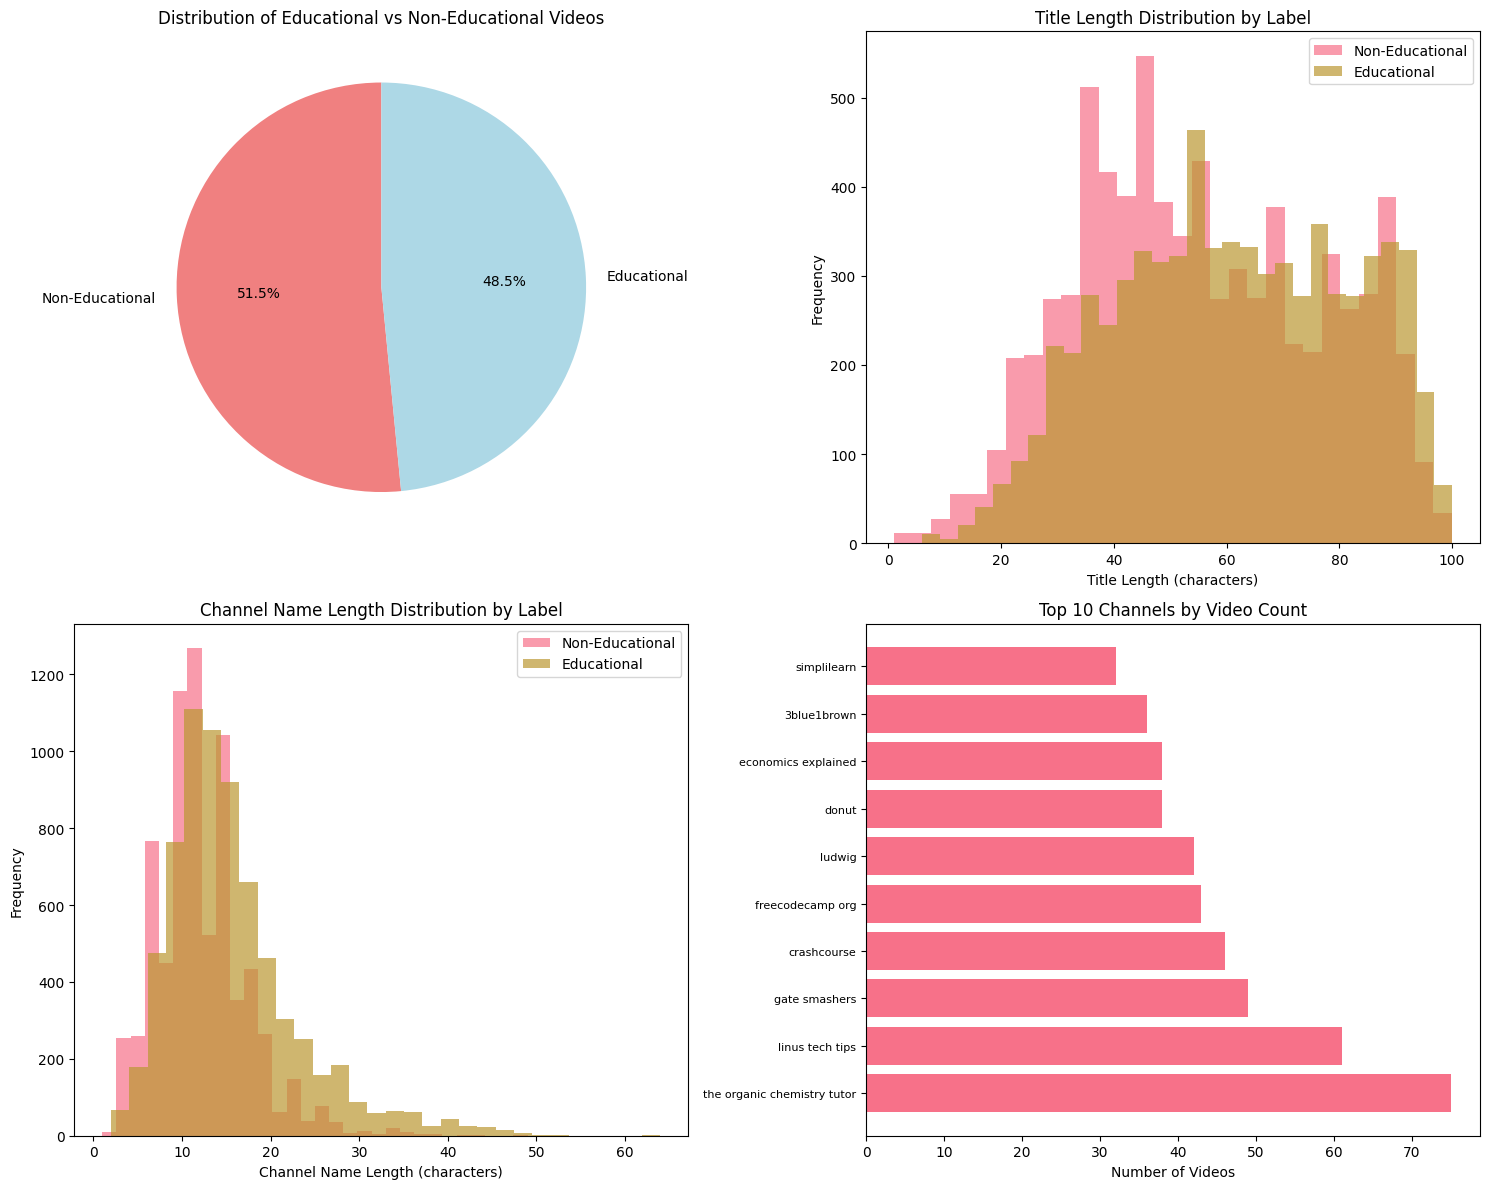


=== TEXT LENGTH STATISTICS ===
Title length - Mean: 58.0, Std: 21.2
Channel length - Mean: 13.9, Std: 6.6


In [5]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Label distribution
label_counts = df['label'].value_counts()
axes[0, 0].pie(label_counts.values, labels=['Non-Educational', 'Educational'], 
               autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightblue'])
axes[0, 0].set_title('Distribution of Educational vs Non-Educational Videos')

# 2. Title length distribution by label
df['title_length'] = df['title'].str.len()
for label in [0, 1]:
    subset = df[df['label'] == label]['title_length']
    axes[0, 1].hist(subset, alpha=0.7, bins=30, 
                    label=f"{'Educational' if label == 1 else 'Non-Educational'}")
axes[0, 1].set_xlabel('Title Length (characters)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Title Length Distribution by Label')
axes[0, 1].legend()

# 3. Channel name length distribution by label
df['channel_length'] = df['channelName'].str.len()
for label in [0, 1]:
    subset = df[df['label'] == label]['channel_length']
    axes[1, 0].hist(subset, alpha=0.7, bins=30,
                    label=f"{'Educational' if label == 1 else 'Non-Educational'}")
axes[1, 0].set_xlabel('Channel Name Length (characters)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Channel Name Length Distribution by Label')
axes[1, 0].legend()

# 4. Top channels by video count
top_channels = df['channelName'].value_counts().head(10)
axes[1, 1].barh(range(len(top_channels)), top_channels.values)
axes[1, 1].set_yticks(range(len(top_channels)))
axes[1, 1].set_yticklabels(top_channels.index, fontsize=8)
axes[1, 1].set_xlabel('Number of Videos')
axes[1, 1].set_title('Top 10 Channels by Video Count')

plt.tight_layout()
plt.show()

print(f"\n=== TEXT LENGTH STATISTICS ===")
print(f"Title length - Mean: {df['title_length'].mean():.1f}, Std: {df['title_length'].std():.1f}")
print(f"Channel length - Mean: {df['channel_length'].mean():.1f}, Std: {df['channel_length'].std():.1f}")


## 3. Feature Engineering


In [6]:
# Text preprocessing function
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (
    REPO_ROOT / "ml" / "scripts" / "preprocessing" / "labeling_processor.py"
).exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "ml" / "scripts" / "preprocessing"))
import labeling_processor

def preprocess_text(text):
    """Clean and preprocess text for feature extraction."""
    if pd.isna(text):
        return ""
    return labeling_processor.clean_text(text)

# Apply preprocessing
print("Preprocessing text features...")
df['title_clean'] = df['title'].apply(preprocess_text)
df['channel_clean'] = df['channelName'].apply(preprocess_text)

# Combine title and channel for comprehensive text features
df['combined_text'] = df['title_clean'] + ' ' + df['channel_clean']

print("Text preprocessing completed!")
print(f"Sample preprocessed titles:")
for i in range(3):
    print(f"Original: {df.iloc[i]['title']}")
    print(f"Cleaned:  {df.iloc[i]['title_clean']}")
    print("---")


Preprocessing text features...
Text preprocessing completed!
Sample preprocessed titles:
Original: 4 apple products you never knew existed
Cleaned:  4 apple products you never knew existed
---
Original: he thought he could beat me speedrunning every game so i embarrassed him
Cleaned:  he thought he could beat me speedrunning every game so i embarrassed him
---
Original: backrooms official trailer hd
Cleaned:  backrooms official trailer hd
---


In [7]:
# Create additional numerical features
print("Creating numerical features...")

# Text length features
df['title_word_count'] = df['title_clean'].str.split().str.len()
df['channel_word_count'] = df['channel_clean'].str.split().str.len()
df['title_char_count'] = df['title_clean'].str.len()
df['channel_char_count'] = df['channel_clean'].str.len()

# Educational keywords (common in educational content)
educational_keywords = [
    'tutorial', 'lesson', 'learn', 'course', 'education', 'teach', 'how to',
    'explained', 'guide', 'training', 'study', 'lecture', 'class', 'exam',
    'homework', 'university', 'school', 'college', 'academic', 'research',
    'science', 'math', 'physics', 'chemistry', 'biology', 'history',
    'programming', 'coding', 'python', 'javascript', 'computer', 'technology'
]

# Count educational keywords in titles and channels
def count_educational_keywords(text):
    if pd.isna(text):
        return 0
    text = str(text).lower()
    return sum(1 for keyword in educational_keywords if keyword in text)

df['edu_keywords_title'] = df['title_clean'].apply(count_educational_keywords)
df['edu_keywords_channel'] = df['channel_clean'].apply(count_educational_keywords)
df['edu_keywords_total'] = df['edu_keywords_title'] + df['edu_keywords_channel']

print("Numerical features created!")
print(f"\n=== FEATURE STATISTICS ===")
feature_cols = ['title_word_count', 'channel_word_count', 'title_char_count', 
                'channel_char_count', 'edu_keywords_total']

for col in feature_cols:
    print(f"{col}:")
    print(f"  Educational (label=1): Mean={df[df['label']==1][col].mean():.2f}")
    print(f"  Non-Educational (label=0): Mean={df[df['label']==0][col].mean():.2f}")
    print()


Creating numerical features...
Numerical features created!

=== FEATURE STATISTICS ===
title_word_count:
  Educational (label=1): Mean=9.60
  Non-Educational (label=0): Mean=9.04

channel_word_count:
  Educational (label=1): Mean=2.39
  Non-Educational (label=0): Mean=1.84

title_char_count:
  Educational (label=1): Mean=61.01
  Non-Educational (label=0): Mean=55.14

channel_char_count:
  Educational (label=1): Mean=15.61
  Non-Educational (label=0): Mean=11.59

edu_keywords_total:
  Educational (label=1): Mean=1.21
  Non-Educational (label=0): Mean=0.05



## 4. Model Training and Evaluation


In [8]:
# Prepare features and target
print("Preparing data for training...")

# Remove rows with missing labels
df_clean = df.dropna(subset=['label']).copy()
print(f"Removed {len(df) - len(df_clean)} rows with missing labels")
print(f"Final dataset size: {len(df_clean)} videos")

# Define feature columns
text_features = ['combined_text']  # We'll use TF-IDF on combined text
numerical_features = ['title_word_count', 'channel_word_count', 'title_char_count', 
                      'channel_char_count', 'edu_keywords_total']

# Prepare target variable
y = df_clean['label'].astype(int)

print(f"Features to use:")
print(f"  Text features: {text_features}")
print(f"  Numerical features: {numerical_features}")
print(f"Target distribution in clean data:")
print(y.value_counts().sort_index())


Preparing data for training...
Removed 0 rows with missing labels
Final dataset size: 14602 videos
Features to use:
  Text features: ['combined_text']
  Numerical features: ['title_word_count', 'channel_word_count', 'title_char_count', 'channel_char_count', 'edu_keywords_total']
Target distribution in clean data:
label
0    7526
1    7076
Name: count, dtype: int64


In [15]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    df_clean, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} videos")
print(f"Test set size: {len(X_test)} videos")
print(f"Training label distribution:")
print(y_train.value_counts().sort_index())
print(f"Test label distribution:")
print(y_test.value_counts().sort_index())

# Create preprocessing pipelines
print("\nSetting up feature preprocessing pipelines...")

# Text preprocessing pipeline (TF-IDF)
text_preprocessor = TfidfVectorizer(
    max_features=5000,          # Limit vocabulary size
    min_df=2,                   # Ignore terms appearing in less than 2 documents
    max_df=0.8,                 # Ignore terms appearing in more than 80% of documents
    ngram_range=(1, 2),         # Use unigrams and bigrams
    stop_words='english',       # Remove English stop words
    lowercase=True,
    token_pattern=r'\b[a-zA-Z][a-zA-Z0-9]*\b'  # Only alphanumeric tokens
)

# Numerical preprocessing pipeline
numerical_preprocessor = StandardScaler()

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_preprocessor, 'combined_text'),
        ('num', numerical_preprocessor, numerical_features)
    ],
    remainder='drop'  # Drop other columns
)

print("Preprocessing pipelines created!")


Training set size: 11681 videos
Test set size: 2921 videos
Training label distribution:
label
0    6020
1    5661
Name: count, dtype: int64
Test label distribution:
label
0    1506
1    1415
Name: count, dtype: int64

Setting up feature preprocessing pipelines...
Preprocessing pipelines created!


In [16]:
# Create and train the model pipeline
print("Training Logistic Regression model...")

# Create the full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'classifier__C': [0.1, 1.0, 10.0],           # Regularization strength
    'classifier__class_weight': [None, 'balanced'], # Handle class imbalance
    'preprocessor__text__max_features': [3000, 5000, 8000],  # TF-IDF vocabulary size
    'preprocessor__text__ngram_range': [(1, 1), (1, 2)]      # n-gram range
}

print("Performing hyperparameter tuning with 5-fold cross-validation...")
print("This may take a few minutes...")

grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='roc_auc',  # Use AUC as the scoring metric
    n_jobs=-1,          # Use all available cores
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation AUC score: {grid_search.best_score_:.4f}")

# Get the best model
best_model = grid_search.best_estimator_


Training Logistic Regression model...
Performing hyperparameter tuning with 5-fold cross-validation...
This may take a few minutes...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'classifier__C': 10.0, 'classifier__class_weight': None, 'preprocessor__text__max_features': 8000, 'preprocessor__text__ngram_range': (1, 1)}
Best cross-validation AUC score: 0.9875


In [17]:
# Evaluate the model on test set
print("Evaluating model performance on test set...")

# Make predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Test Set Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {auc_score:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Educational', 'Educational']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Non-Edu  Educational")
print(f"Actual Non-Edu     {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"Actual Educational {cm[1,0]:3d}      {cm[1,1]:3d}")

# Cross-validation scores for additional validation
print(f"\nCross-validation scores on full training set:")
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Evaluating model performance on test set...
Test Set Performance:
Accuracy: 0.9531
ROC-AUC: 0.9896

Detailed Classification Report:
                 precision    recall  f1-score   support

Non-Educational       0.94      0.97      0.96      1506
    Educational       0.97      0.94      0.95      1415

       accuracy                           0.95      2921
      macro avg       0.95      0.95      0.95      2921
   weighted avg       0.95      0.95      0.95      2921


Confusion Matrix:
                 Predicted
                 Non-Edu  Educational
Actual Non-Edu     1459       47
Actual Educational  90      1325

Cross-validation scores on full training set:
CV AUC scores: [0.98806127 0.98981568 0.98707855 0.9865811  0.98586132]
Mean CV AUC: 0.9875 (+/- 0.0027)


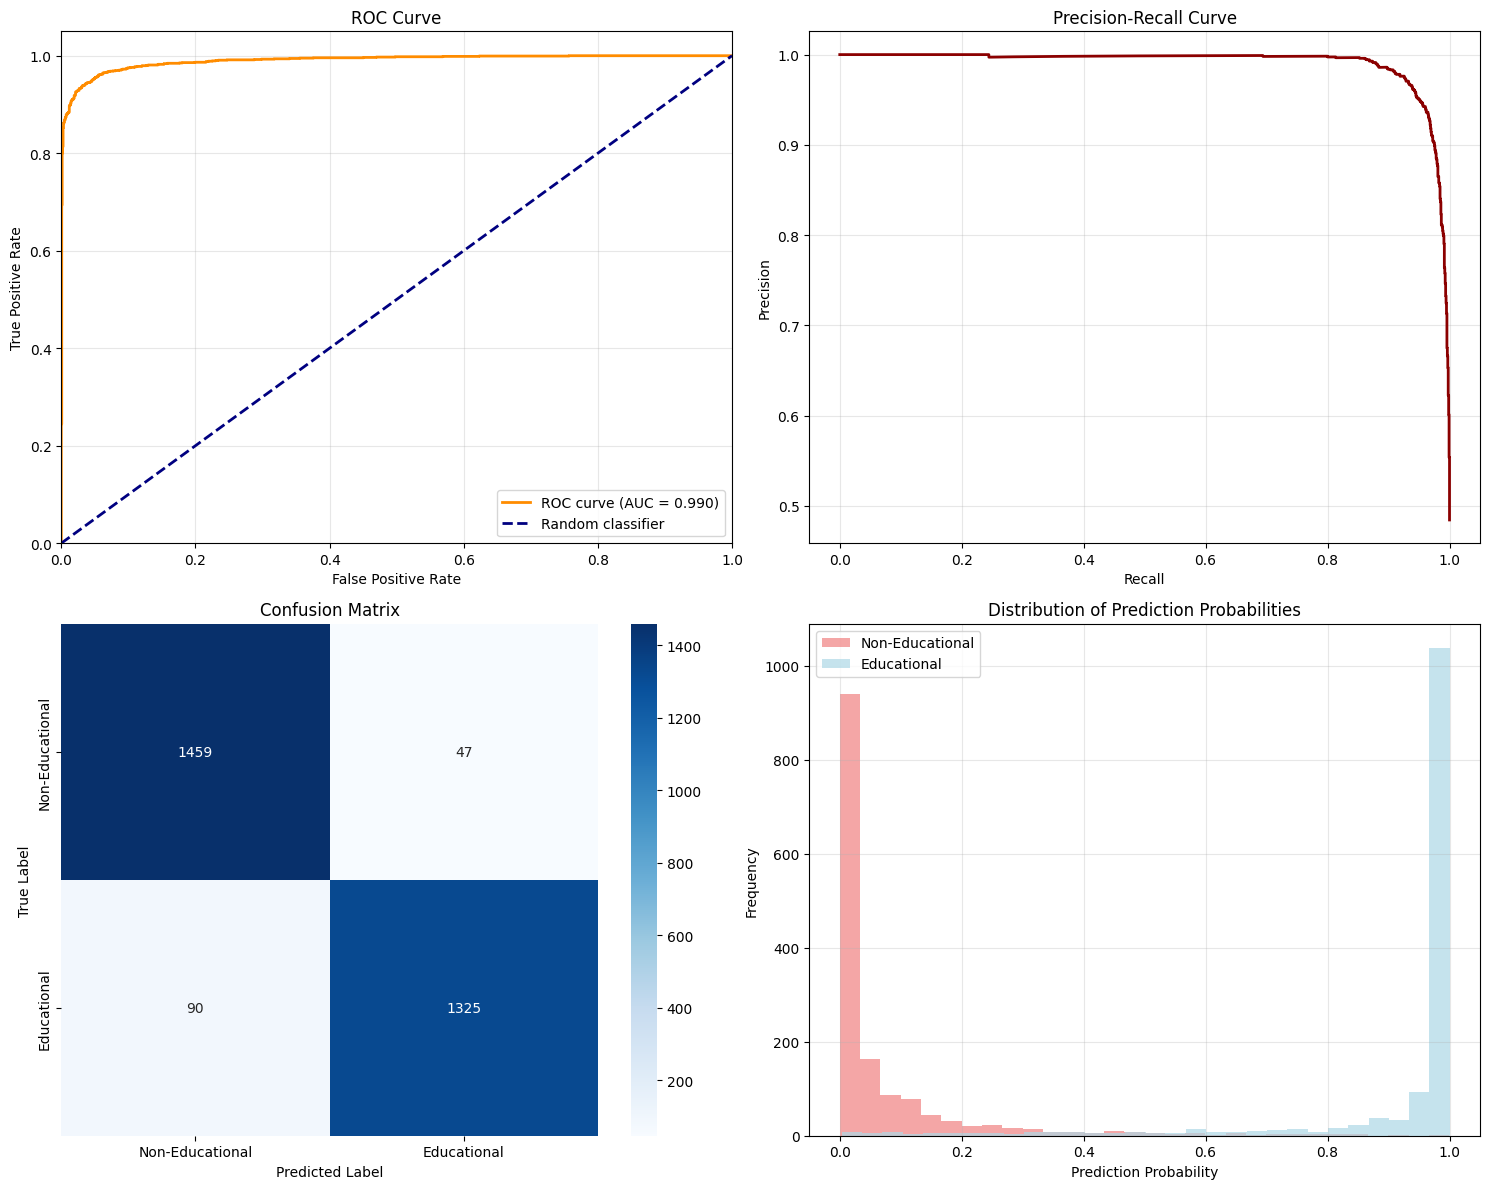

In [12]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(True, alpha=0.3)

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[0, 1].plot(recall, precision, color='darkred', lw=2)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Educational', 'Educational'],
            yticklabels=['Non-Educational', 'Educational'],
            ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# 4. Prediction Probability Distribution
axes[1, 1].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, 
                label='Non-Educational', color='lightcoral')
axes[1, 1].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, 
                label='Educational', color='lightblue')
axes[1, 1].set_xlabel('Prediction Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Prediction Probabilities')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Analyzing feature importance...
Top 15 features most indicative of EDUCATIONAL content:
  philosophy                                         +8.5319
  introduction                                       +8.3199
  psychology                                         +7.7376
  sql                                                +7.0208
  basics                                             +6.7533
  spanish                                            +6.7115
  theory                                             +6.6645
  sat                                                +6.6046
  guitar                                             +6.5728
  explained                                          +6.4631
  github                                             +6.1591
  data                                               +6.1412
  calculus                                           +6.1087
  excel                                              +5.9160
  ai                                                 +5.47

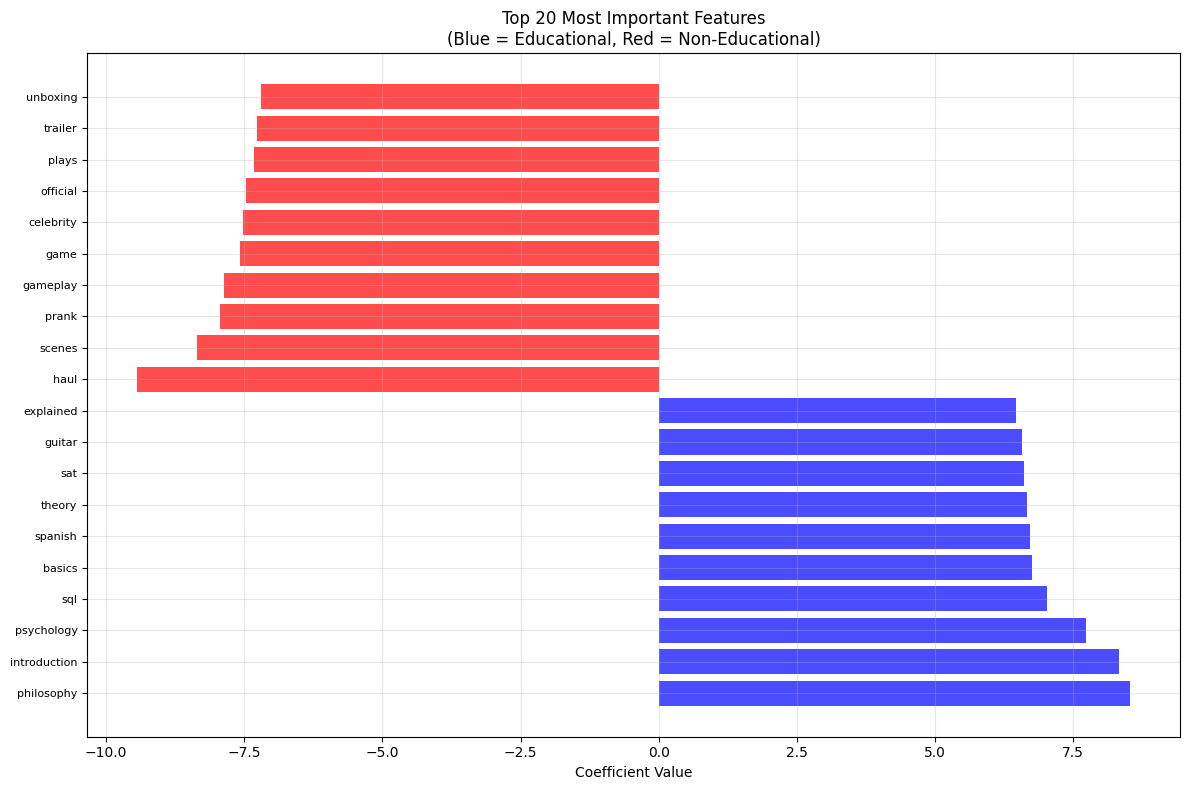

In [18]:
# Feature importance analysis
print("Analyzing feature importance...")

# Get feature names from the preprocessor
tfidf_feature_names = best_model.named_steps['preprocessor'].named_transformers_['text'].get_feature_names_out()
numerical_feature_names = numerical_features

# Combine all feature names
all_feature_names = list(tfidf_feature_names) + numerical_feature_names

# Get coefficients from logistic regression
coefficients = best_model.named_steps['classifier'].coef_[0]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

# Display top positive and negative features
print("Top 15 features most indicative of EDUCATIONAL content:")
top_educational = feature_importance.nlargest(15, 'coefficient')
for idx, row in top_educational.iterrows():
    print(f"  {row['feature'][:50]:50s} {row['coefficient']:+.4f}")

print(f"\nTop 15 features most indicative of NON-EDUCATIONAL content:")
top_non_educational = feature_importance.nsmallest(15, 'coefficient')
for idx, row in top_non_educational.iterrows():
    print(f"  {row['feature'][:50]:50s} {row['coefficient']:+.4f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = pd.concat([
    feature_importance.nlargest(10, 'coefficient'),
    feature_importance.nsmallest(10, 'coefficient')
])

colors = ['red' if coef < 0 else 'blue' for coef in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), [f[:30] for f in top_features['feature']], fontsize=8)
plt.xlabel('Coefficient Value')
plt.title('Top 20 Most Important Features\n(Blue = Educational, Red = Non-Educational)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Model Saving and Testing


In [19]:
# Save the trained model
import joblib
from datetime import datetime

print("Saving the trained model...")

# Create model directory if it doesn't exist
model_dir = Path("trained_models")
model_dir.mkdir(exist_ok=True)

# Save the complete pipeline
model_path = model_dir / "educational_video_classifier.joblib"
joblib.dump(best_model, model_path)

# Get feature names from the preprocessor for metadata
tfidf_feature_names = best_model.named_steps['preprocessor'].named_transformers_['text'].get_feature_names_out()

# Save model metadata
metadata = {
    'model_type': 'Logistic Regression',
    'training_date': datetime.now().isoformat(),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'features_used': {
        'text_features': text_features,
        'numerical_features': numerical_features
    },
    'best_params': grid_search.best_params_,
    'performance': {
        'test_accuracy': float(accuracy),
        'test_auc': float(auc_score),
        'cv_auc_mean': float(cv_scores.mean()),
        'cv_auc_std': float(cv_scores.std())
    },
    'preprocessing': {
        'tfidf_vocabulary_size': len(tfidf_feature_names),
        'educational_keywords': educational_keywords
    }
}

metadata_path = model_dir / "model_metadata.json"
import json
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Model saved to: {model_path}")
print(f"Metadata saved to: {metadata_path}")
print(f"Model size: {model_path.stat().st_size / 1024 / 1024:.2f} MB")


Saving the trained model...
Model saved to: trained_models\educational_video_classifier.joblib
Metadata saved to: trained_models\model_metadata.json
Model size: 0.34 MB


In [20]:
# Test the model with some example predictions
print("Testing the model with example videos...")

# Function to predict a single video
def predict_video(title, channel_name, model=best_model):
    """Predict if a video is educational based on title and channel name"""
    # Create a DataFrame with the same structure as training data
    test_data = pd.DataFrame({
        'title': [title],
        'channelName': [channel_name],
        'title_clean': [preprocess_text(title)],
        'channel_clean': [preprocess_text(channel_name)],
    })
    
    # Add the combined text and numerical features
    test_data['combined_text'] = test_data['title_clean'] + ' ' + test_data['channel_clean']
    test_data['title_word_count'] = test_data['title_clean'].str.split().str.len()
    test_data['channel_word_count'] = test_data['channel_clean'].str.split().str.len()
    test_data['title_char_count'] = test_data['title_clean'].str.len()
    test_data['channel_char_count'] = test_data['channel_clean'].str.len()
    test_data['edu_keywords_title'] = test_data['title_clean'].apply(count_educational_keywords)
    test_data['edu_keywords_channel'] = test_data['channel_clean'].apply(count_educational_keywords)
    test_data['edu_keywords_total'] = test_data['edu_keywords_title'] + test_data['edu_keywords_channel']
    
    # Make prediction
    prediction = model.predict(test_data)[0]
    probability = model.predict_proba(test_data)[0, 1]
    
    return prediction, probability

# Test with example videos
test_cases = [
    ("Python Programming Tutorial for Beginners", "CodeWithMosh"),
    ("Funny Cat Videos Compilation 2024", "FunnyPets"),
    ("Introduction to Machine Learning", "MIT OpenCourseWare"),
    ("Top 10 Celebrity Fashion Fails", "Entertainment Tonight"),
    ("Calculus Explained: Derivatives and Integrals", "Khan Academy"),
    ("Epic Gaming Moments and Fails", "PewDiePie"),
    ("How to Build a REST API with Node.js", "TechTutorials"),
    ("Daily Vlog: Shopping and Coffee", "LifestyleVlogger")
]

print("Example predictions:")
print("=" * 80)
for title, channel in test_cases:
    pred, prob = predict_video(title, channel)
    label = "Educational" if pred == 1 else "Non-Educational"
    print(f"Title: {title[:50]:50s}")
    print(f"Channel: {channel[:30]:30s}")
    print(f"Prediction: {label:15s} (Confidence: {prob:.3f})")
    print("-" * 80)


Testing the model with example videos...
Example predictions:
Title: Python Programming Tutorial for Beginners         
Channel: CodeWithMosh                  
Prediction: Educational     (Confidence: 1.000)
--------------------------------------------------------------------------------
Title: Funny Cat Videos Compilation 2024                 
Channel: FunnyPets                     
Prediction: Non-Educational (Confidence: 0.020)
--------------------------------------------------------------------------------
Title: Introduction to Machine Learning                  
Channel: MIT OpenCourseWare            
Prediction: Educational     (Confidence: 0.999)
--------------------------------------------------------------------------------
Title: Top 10 Celebrity Fashion Fails                    
Channel: Entertainment Tonight         
Prediction: Non-Educational (Confidence: 0.009)
--------------------------------------------------------------------------------
Title: Calculus Explained: Der

## 6. Summary and Next Steps


In [21]:
# Print comprehensive summary
print("🎉 EDUCATIONAL VIDEO CLASSIFICATION MODEL - TRAINING COMPLETE! 🎉")
print("=" * 80)
print(f"Dataset Statistics:")
print(f"  • Total videos processed: {len(df_clean):,}")
print(f"  • Educational videos: {(y == 1).sum():,} ({(y == 1).mean()*100:.1f}%)")
print(f"  • Non-educational videos: {(y == 0).sum():,} ({(y == 0).mean()*100:.1f}%)")
print(f"  • Training set: {len(X_train):,} videos")
print(f"  • Test set: {len(X_test):,} videos")

print(f"\nModel Performance:")
print(f"  • Test Accuracy: {accuracy:.1%}")
print(f"  • Test ROC-AUC: {auc_score:.3f}")
print(f"  • Cross-validation AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

print(f"\nModel Configuration:")
print(f"  • Algorithm: {metadata['model_type']}")
print(f"  • TF-IDF Features: {metadata['preprocessing']['tfidf_vocabulary_size']:,}")
print(f"  • Numerical Features: {len(numerical_features)}")
print(f"  • Best Parameters: {grid_search.best_params_}")

print(f"\nModel Artifacts:")
print(f"  • Model file: {model_path}")
print(f"  • Metadata file: {metadata_path}")
print(f"  • Model size: {model_path.stat().st_size / 1024 / 1024:.2f} MB")

print(f"\n🚀 Next Steps:")
print(f"  1. Use the saved model with: joblib.load('{model_path}')")
print(f"  2. Run predictions with: python predict_video.py")
print(f"  3. Deploy the model to production")
print(f"  4. Collect more data to improve performance")
print(f"  5. Experiment with advanced models (BERT, XGBoost)")

print(f"\n✅ Model ready for deployment and production use!")
print("=" * 80)


🎉 EDUCATIONAL VIDEO CLASSIFICATION MODEL - TRAINING COMPLETE! 🎉
Dataset Statistics:
  • Total videos processed: 14,602
  • Educational videos: 7,076 (48.5%)
  • Non-educational videos: 7,526 (51.5%)
  • Training set: 11,681 videos
  • Test set: 2,921 videos

Model Performance:
  • Test Accuracy: 95.3%
  • Test ROC-AUC: 0.990
  • Cross-validation AUC: 0.987 ± 0.001

Model Configuration:
  • Algorithm: Logistic Regression
  • TF-IDF Features: 8,000
  • Numerical Features: 5
  • Best Parameters: {'classifier__C': 10.0, 'classifier__class_weight': None, 'preprocessor__text__max_features': 8000, 'preprocessor__text__ngram_range': (1, 1)}

Model Artifacts:
  • Model file: trained_models\educational_video_classifier.joblib
  • Metadata file: trained_models\model_metadata.json
  • Model size: 0.34 MB

🚀 Next Steps:
  1. Use the saved model with: joblib.load('trained_models\educational_video_classifier.joblib')
  2. Run predictions with: python predict_video.py
  3. Deploy the model to producti